In [53]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, r2_score
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

# --- LOAD DATA ---
df = pd.read_csv("cleaned_patient_with_hospital.csv")

# --- FILTER DISEASE ---
df = df[df["disease_type"].str.lower().str.contains("diarrhea")].copy()

In [54]:
# --- PARSE DATE ---
df["date_disease_start"] = pd.to_datetime(
    df["date_disease_start"],
    dayfirst=True,
    errors="coerce"
)
df = df.dropna(subset=["date_disease_start"])
df["year"] = df["date_disease_start"].dt.year
df["week"] = df["date_disease_start"].dt.isocalendar().week
# --- Compute patient-level binary features ---
df["is_inpatient"]     = (df["patient_type"] == "inpatient").astype(int)
df["is_in_care"]       = (df["patient_status"] == "in_care").astype(int)
df["is_recovered"]     = (df["patient_status"] == "recovered").astype(int)
df["is_high_risk_age"] = ((df["age"] < 5) | (df["age"] >= 60)).astype(int)
# --- AGGREGATE ---
weekly_cases = (
    df.groupby(["district", "year", "week"])
    .agg(
        case_count          = ("district",        "size"),
        inpatient_count     = ("is_inpatient",    "sum"),
        in_care_count       = ("is_in_care",      "sum"),
        recovered_count     = ("is_recovered",    "sum"),
        high_risk_age_ratio = ("is_high_risk_age","mean"),
    )
    .reset_index()
)

# --- Convert counts to ratios ---
weekly_cases["inpatient_ratio"] = weekly_cases["inpatient_count"] / weekly_cases["case_count"]
weekly_cases["in_care_rate"]    = weekly_cases["in_care_count"]   / weekly_cases["case_count"]
weekly_cases["recovery_rate"]   = weekly_cases["recovered_count"] / weekly_cases["case_count"]
# --- Drop raw counts ---
weekly_cases = weekly_cases.drop(columns=["inpatient_count", "in_care_count", "recovered_count"])
# Sort properly for lag features
weekly_cases["date"] = pd.to_datetime(
    weekly_cases["year"].astype(str) + "-W" + weekly_cases["week"].astype(str) + "-1",
    format="%G-W%V-%u"   # ISO week format
)
weekly_cases = weekly_cases.sort_values(["district", "date"])
weekly_cases.head()

,district,year,week,case_count,high_risk_age_ratio,inpatient_ratio,in_care_rate,recovery_rate,date
0,bang_bon,2026,1,38,0.236842,0.263158,0.263158,0.000000,2025-12-29
1,bang_bon,2026,2,67,0.268657,0.164179,0.179104,0.059701,2026-01-05
2,bang_bon,2026,3,99,0.303030,0.232323,0.212121,0.000000,2026-01-12
3,bang_bon,2026,4,81,0.246914,0.172840,0.172840,0.049383,2026-01-19
4,bang_bon,2026,5,77,0.272727,0.233766,0.168831,0.000000,2026-01-26


In [55]:
# --- FEATURE ENGINEERING ---
weekly_cases["lag_1"] = weekly_cases.groupby("district")["case_count"].shift(1)
weekly_cases["lag_2"] = weekly_cases.groupby("district")["case_count"].shift(2)

weekly_cases["rolling_avg_2"] = weekly_cases[["lag_1", "lag_2"]].mean(axis=1)
weekly_cases["rolling_max_2"] = weekly_cases[["lag_1", "lag_2"]].max(axis=1)

weekly_cases["week_of_year"] = weekly_cases["week"]

# Drop rows with NaN (from lag)
weekly_cases[["lag_1", "lag_2"]] = weekly_cases[["lag_1", "lag_2"]].fillna(0)

# --- LABEL CREATION ---
split_date = weekly_cases['date'].quantile(0.8)
train_temp = weekly_cases[weekly_cases['date'] <= split_date]
threshold = np.percentile(train_temp["case_count"], 75)
weekly_cases["label"] = (weekly_cases["case_count"] > threshold).astype(int)
weekly_cases.head()

,district,year,week,case_count,high_risk_age_ratio,inpatient_ratio,in_care_rate,recovery_rate,date,lag_1,lag_2,rolling_avg_2,rolling_max_2,week_of_year,label
0,bang_bon,2026,1,38,0.236842,0.263158,0.263158,0.000000,2025-12-29,0.0,0.0,NaN,NaN,1,0
1,bang_bon,2026,2,67,0.268657,0.164179,0.179104,0.059701,2026-01-05,38.0,0.0,38.0,38.0,2,0
2,bang_bon,2026,3,99,0.303030,0.232323,0.212121,0.000000,2026-01-12,67.0,38.0,52.5,67.0,3,1
3,bang_bon,2026,4,81,0.246914,0.172840,0.172840,0.049383,2026-01-19,99.0,67.0,83.0,99.0,4,1
4,bang_bon,2026,5,77,0.272727,0.233766,0.168831,0.000000,2026-01-26,81.0,99.0,90.0,99.0,5,1


In [56]:
weekly_cases = weekly_cases.sort_values(['district','date']).reset_index(drop=True)
train_set = weekly_cases[weekly_cases['date'] <= split_date]
test_set = weekly_cases[weekly_cases['date'] > split_date]
train_set.head()

,district,year,week,case_count,high_risk_age_ratio,inpatient_ratio,in_care_rate,recovery_rate,date,lag_1,lag_2,rolling_avg_2,rolling_max_2,week_of_year,label
0,bang_bon,2026,1,38,0.236842,0.263158,0.263158,0.000000,2025-12-29,0.0,0.0,NaN,NaN,1,0
1,bang_bon,2026,2,67,0.268657,0.164179,0.179104,0.059701,2026-01-05,38.0,0.0,38.0,38.0,2,0
2,bang_bon,2026,3,99,0.303030,0.232323,0.212121,0.000000,2026-01-12,67.0,38.0,52.5,67.0,3,1
3,bang_bon,2026,4,81,0.246914,0.172840,0.172840,0.049383,2026-01-19,99.0,67.0,83.0,99.0,4,1
4,bang_bon,2026,5,77,0.272727,0.233766,0.168831,0.000000,2026-01-26,81.0,99.0,90.0,99.0,5,1


In [57]:
# --- FEATURES / TARGET ---
features = ["lag_1", "lag_2", "rolling_avg_2", "rolling_max_2", "week_of_year", 
            "inpatient_ratio", "in_care_rate", "recovery_rate"]
target = "label"

X_train = train_set[features]
y_train = train_set[target]

X_test = test_set[features]
y_test = test_set[target]
X_train.head()

,lag_1,lag_2,rolling_avg_2,rolling_max_2,week_of_year,inpatient_ratio,in_care_rate,recovery_rate
0,0.0,0.0,NaN,NaN,1,0.263158,0.263158,0.000000
1,38.0,0.0,38.0,38.0,2,0.164179,0.179104,0.059701
2,67.0,38.0,52.5,67.0,3,0.232323,0.212121,0.000000
3,99.0,67.0,83.0,99.0,4,0.172840,0.172840,0.049383
4,81.0,99.0,90.0,99.0,5,0.233766,0.168831,0.000000


## Predicting Outbreak

In [58]:
# --- MODEL ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- EVALUATION ---
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
test_set = test_set.copy()
test_set["pred"] = y_pred

# Show test results with district
print(test_set[["district", "week", "pred", "label"]])

# --- PREDICTION (LATEST PER DISTRICT) ---
# latest_rows = weekly_cases.sort_values("date").groupby("district").tail(1)
# latest_rows["prediction"] = model.predict(latest_rows[features])

# # Flag districts
# flagged = latest_rows[latest_rows["prediction"] == 1]

# print("\nDistricts needing diarrhea medicine:")
# print(flagged[["district", "prediction"]])

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       115
           1       0.62      0.91      0.74        11

    accuracy                           0.94       126
   macro avg       0.81      0.93      0.85       126
weighted avg       0.96      0.94      0.95       126

      district  week  pred  label
11    bang_bon    12     0      0
12    bang_bon    13     0      0
13    bang_bon    14     0      0
25   bang_kapi    12     0      0
26   bang_kapi    13     0      0
..         ...   ...   ...    ...
660   watthana    12     1      1
661   watthana    13     1      0
673   yan_nawa    12     0      0
674   yan_nawa    13     0      0
675   yan_nawa    14     0      0

[126 rows x 4 columns]


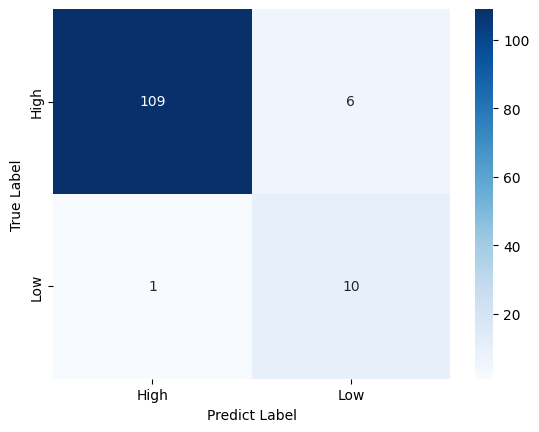

In [60]:
cf=metrics.confusion_matrix(test_set['label'],test_set['pred'])
sns.heatmap(cf,annot=True, fmt='d',cmap='Blues',xticklabels=['High','Low'],yticklabels=['High','Low'])
plt.ylabel("True Label")
plt.xlabel("Predict Label")
plt.show()

## Predicting Medicine Required

In [61]:
# --- FEATURES / TARGET ---
features = ["lag_1", "lag_2", "rolling_avg_2", "rolling_max_2", "week_of_year", 
            "inpatient_ratio", "in_care_rate", "recovery_rate"]
target = "case_count"

X_train = train_set[features]
y_train = train_set[target]

X_test = test_set[features]
y_test = test_set[target]
X_train.head()

,lag_1,lag_2,rolling_avg_2,rolling_max_2,week_of_year,inpatient_ratio,in_care_rate,recovery_rate
0,0.0,0.0,NaN,NaN,1,0.263158,0.263158,0.000000
1,38.0,0.0,38.0,38.0,2,0.164179,0.179104,0.059701
2,67.0,38.0,52.5,67.0,3,0.232323,0.212121,0.000000
3,99.0,67.0,83.0,99.0,4,0.172840,0.172840,0.049383
4,81.0,99.0,90.0,99.0,5,0.233766,0.168831,0.000000


In [62]:
# --- MODEL ---
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- EVALUATION ---
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("MSE: ", mse)
print("R2: ", r2)

test_set = test_set.copy()
test_set['pred'] = y_pred
print(test_set[['district', 'week', 'pred', 'case_count']])

MAE: 15.575952380952382
MSE:  496.96549285714275
R2:  0.22680385197461972
      district  week   pred  case_count
11    bang_bon    12  39.37          32
12    bang_bon    13  37.50          30
13    bang_bon    14  23.76           3
25   bang_kapi    12  65.69          51
26   bang_kapi    13  62.68          51
..         ...   ...    ...         ...
660   watthana    12  97.02          89
661   watthana    13  93.00           8
673   yan_nawa    12  30.34          29
674   yan_nawa    13  29.42          21
675   yan_nawa    14  20.20           3

[126 rows x 4 columns]


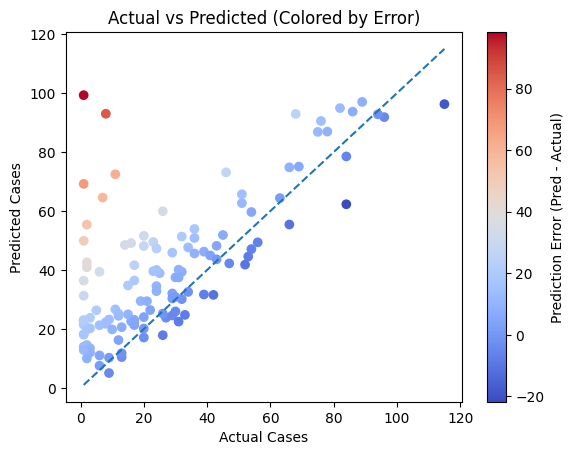

In [63]:
error = y_pred - y_test

plt.scatter(y_test, y_pred, c=error, cmap="coolwarm")
plt.colorbar(label="Prediction Error (Pred - Actual)")

plt.xlabel("Actual Cases")
plt.ylabel("Predicted Cases")
plt.title("Actual vs Predicted (Colored by Error)")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")

plt.show()

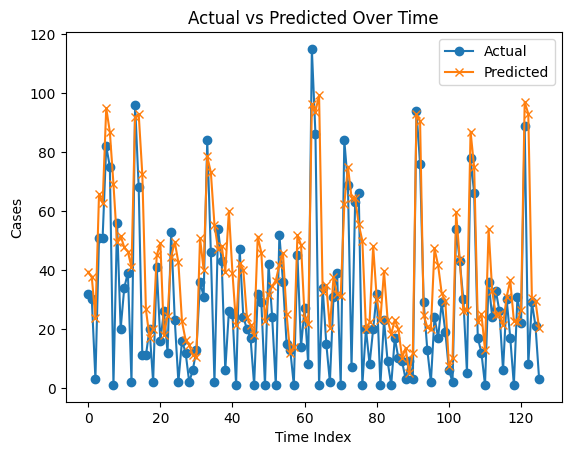

In [64]:
plt.plot(y_test.values, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')

plt.xlabel("Time Index")
plt.ylabel("Cases")
plt.title("Actual vs Predicted Over Time")

plt.legend()
plt.show()